In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score,roc_curve,auc


In [2]:
df=pd.read_csv('https://raw.githubusercontent.com/amirah1921/DailyDelhiDataset/refs/heads/main/DailyDelhiClimateTest.csv')
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333


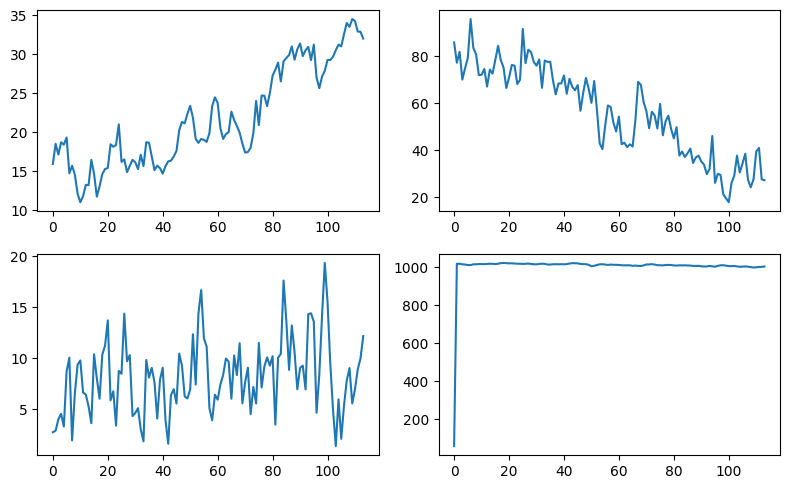

In [3]:
plots=["meantemp","humidity","wind_speed","meanpressure"]
titles=["Tempreatire","Humidity","WindSpeed","Pressure"]
fig,axs=plt.subplots(2,2,figsize=(8,5))
axs=axs.flatten()
for i,ax in enumerate(axs):
    ax.plot(df[plots[i]])
    ax.xticks=([])
    ax.set_ylabel=titles[i]

plt.tight_layout()
plt.show()

In [5]:
df.describe()

,meantemp,humidity,wind_speed,meanpressure
count,114.000000,114.000000,114.000000,114.000000
mean,21.713079,56.258362,8.143924,1004.035090
std,6.360072,19.068083,3.588049,89.474692
min,11.000000,17.750000,1.387500,59.000000
25%,16.437198,39.625000,5.563542,1007.437500
50%,19.875000,57.750000,8.069444,1012.739316
75%,27.705357,71.902778,10.068750,1016.739583
max,34.500000,95.833333,19.314286,1022.809524


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          114 non-null    str    
 1   meantemp      114 non-null    float64
 2   humidity      114 non-null    float64
 3   wind_speed    114 non-null    float64
 4   meanpressure  114 non-null    float64
dtypes: float64(4), str(1)
memory usage: 4.6 KB


In [4]:
X= df[['humidity', 'wind_speed', 'meanpressure']]
y_temp=df['meantemp']

In [30]:
model=LRegression(learning_rate=0.01,epochs=1000)
model.fit(X_train,y_train)

C:\Users\narin\AppData\Local\Temp\ipykernel_8792\71302879.py:25: RuntimeWarning: overflow encountered in dot
  dw = (2 / n_samples) * np.dot(X.T, (y_pred - y))
c:\NITJ\Fourth\IML-Lab\lab\Lib\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
C:\Users\narin\AppData\Local\Temp\ipykernel_8792\71302879.py:29: RuntimeWarning: invalid value encountered in subtract
  self.w -= self.lr * dw
C:\Users\narin\AppData\Local\Temp\ipykernel_8792\71302879.py:30: RuntimeWarning: invalid value encountered in scalar subtract
  self.b -= self.lr * db


In [31]:
poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=3)),
    ('linear', LinearRegression())
])
poly_model.fit(X_train, y_train)
y_pred_poly = poly_model.predict(X_test)

In [32]:
y_pred=model.predict(X_test)

In [33]:
model1=LinearRegression(n_jobs=16)
model1.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",16
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [34]:
y_pred1 = model1.predict(X_test)


In [35]:
def r2_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    return 1 - (ss_res / ss_tot)


In [36]:
print(f"R2 score for hardcoded linear-regression:{r2_score(y_test,y_pred)}")
print(f"R2 score for sklearn linear-regression:{r2_score(y_test,y_pred1)}")

R2 score for hardcoded linear-regression:nan
R2 score for sklearn linear-regression:-6.35660074096421


c:\NITJ\Fourth\IML-Lab\lab\Lib\site-packages\sklearn\metrics\_ranking.py:1294: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
c:\NITJ\Fourth\IML-Lab\lab\Lib\site-packages\sklearn\metrics\_ranking.py:1294: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


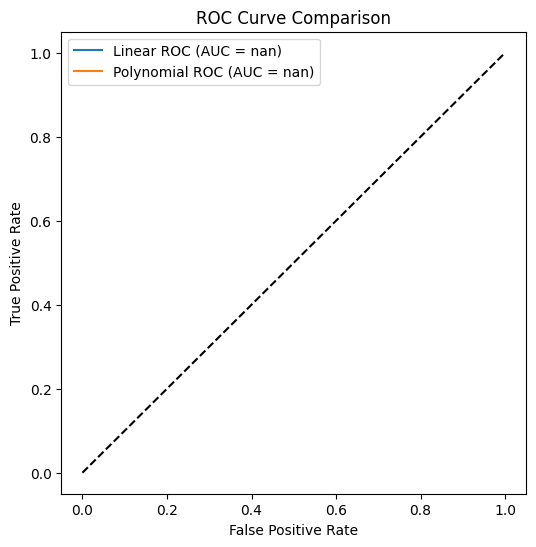

In [37]:
# Convert regression to classification (threshold = 25°C)
y_test_class = (y_test > 25).astype(int)

# ROC Curve
fpr_lin, tpr_lin, _ = roc_curve(y_test_class, y_pred1)
fpr_poly, tpr_poly, _ = roc_curve(y_test_class, y_pred_poly)

plt.figure(figsize=(6,6))
plt.plot(fpr_lin, tpr_lin, label="Linear ROC (AUC = %.2f)" % auc(fpr_lin, tpr_lin))
plt.plot(fpr_poly, tpr_poly, label="Polynomial ROC (AUC = %.2f)" % auc(fpr_poly, tpr_poly))
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()